# Assignment 03

The following assignment is divided in two parts:
- Part A: Run the cells that have already been coded for you to see and understand how Convolution 2D kernel works and, at the end, respond to the questions 1a, 1b, 2a, 2b
- Part B:  Run the cells that have already been coded for you to train the given Neural Network and then respond to the questions 03 to 10 in your video

**Note:**

Coding: 5%
video presentation: 5%
Total: 10%
But without YouTube presentation you receive no mark for the submission. In short, only submissions with YouTube link will be marked.

# PART A

## Image Convolution

In [1]:
# Import the necessary packages and libraries
import numpy as np
from PIL import Image
from scipy import misc
from skimage import data
from skimage.color import rgb2gray
import matplotlib.pyplot as plt
%matplotlib inline
import requests
from io import BytesIO

/tmp/ipykernel_1511/2672511126.py:4: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc


## Import the image

In [ ]:
# Get the image from the URL
response = requests.get('https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTAHCp2ppBbfcPk9S5nE8gFFsZpDh0Exv9qUKXjehk_QszZHsV_pw&s')

In [ ]:
# Visualize the content of the response
print(response.content)

b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00\x84\x00\t\x06\x07\x12\x13\x12\x15\x13\x13\x12\x16\x16\x15\x15\x17\x17\x16\x15\x17\x18\x17\x17\x17\x17\x17\x17\x15\x15\x16\x17\x15\x17\x15\x19\x19\x1d( \x18\x1b&\x1b\x15\x15!1!%)+...\x17\x1f383-7(-.+\x01\n\n\n\x0e\r\x0e\x1a\x10\x10\x1b-&\x1e%--------------------+--//--------/----------------\xff\xc0\x00\x11\x08\x00\x8c\x01g\x03\x01\x11\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1c\x00\x00\x01\x05\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x02\x03\x04\x05\x06\x01\x07\x08\xff\xc4\x00L\x10\x00\x02\x00\x03\x05\x04\x06\x06\x05\t\x06\x05\x05\x01\x00\x00\x01\x02\x00\x03\x11\x04\x05\x12!1\x06AQq\x07\x13a\x81\x91\xa1"2Br\xb1\xc1#R\xd1\xe1\xf03Cb\x82\x92\xa2\xb2\xc2\xd2\x08\x14DSs\x93\x16\x17ET\xf14c\xa3\xb3\xe2\x15\xff\xc4\x00\x1b\x01\x01\x00\x03\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\xff\xc4\x00<\x11\x00\x02\x01\x02\x02\x06\x06\n\x00\x04\x07\x01\x00\x00\x00\

In [ ]:
# BytesIO() buffers the image into the RAM
# Image.open() opens the buffered image
# np.array() transforms the image into a 3D array containing values from 0-255 corresponding to the RGB colour channels
input_img_arr = np.array(Image.open(BytesIO(response.content)))

## First let’s see the Image.




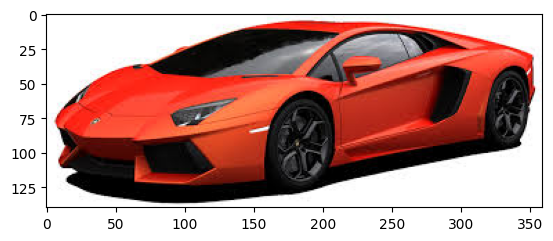

In [ ]:
# Plot the resulting image from the array
plt.imshow(input_img_arr)

In [ ]:
# Print the array shape
print(input_img_arr.shape)

# Compare the values of colour channels 0 and 1
print(np.array_equal(
        input_img_arr[:, :, 0],
        input_img_arr[:, :, 1]))

# Compare the values of colour channels 1 and 2
print(np.array_equal(
        input_img_arr[:, :, 1],
        input_img_arr[:, :, 2]))

(140, 359, 3)
False
False


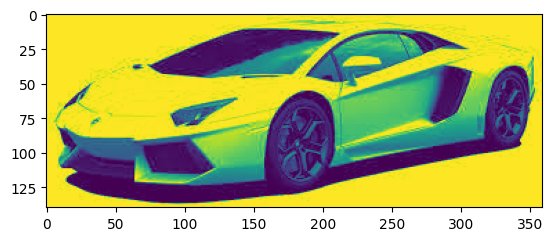

In [ ]:
# Save the colour channel 0 in to the input_img_arr array variable and print it
input_img_arr = input_img_arr[:, :, 0]
plt.imshow(input_img_arr)

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
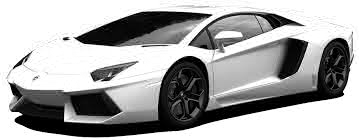

In [ ]:
# Visualize the values inside of the resulting array
input_img_arr[:, :]

## Convolution with 2-D Kernels

How Convolution works?
https://miro.medium.com/max/790/1*1okwhewf5KCtIPaFib4XaA.gif

In [ ]:
# Create a padded array by adding 2 rows and 2 columns (one of each at the beginning and another of each at the end)
padded_array = np.pad(input_img_arr, (1, 1), 'constant')

# Create the kernel
kernel = np.array([[0, 0, 0],
                   [0, 1, 0],
                   [0, 0, 0]])

#Create an output array filled with zeros with the same shape of input_img_arr
output_array = np.zeros(input_img_arr.shape)

In [ ]:
#Compare both arrays
print("Original array shape:",input_img_arr.shape)
print("Padded array shape:",padded_array.shape)

Original array shape: (140, 359)
Padded array shape: (142, 361)


In [ ]:
#Apply the kernel to the array values
for i in range(padded_array.shape[0]-2):
    for j in range(padded_array.shape[1]-2):
        temp_array = padded_array[i:i+3, j:j+3]
        output_array[i, j] = np.sum(temp_array*kernel)

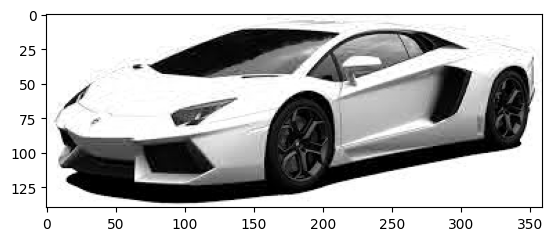

In [ ]:
#Plot the resulting array
plt.imshow(output_array, cmap = plt.get_cmap('gray'))

## Standard Convolution

In [ ]:
# Define a function to trim out the values between 0-255 range.
# This function will be called in the following function since the resulting array values can be negative or greater than 255
def squash_pixel_value(value):
    if value < 0:
        return 0
    elif value < 255:
        return value
    else:
        return 255

In [ ]:
#Define a function to apply a Conv 2D Kernel to an image
def conv_2d_kernel(image_array_2d, kernel, squash_pixels = True):
    padded_array = np.pad(image_array_2d, (1, 1), 'constant')

    kernel_width = kernel.shape[0]
    kernel_height = kernel.shape[1]

    transformed_array = np.zeros(image_array_2d.shape)

    for i in range(padded_array.shape[0] - kernel_width + 1):
        for j in range(padded_array.shape[1] - kernel_height + 1):
            temp_array = padded_array[i:i+kernel_width, j:j+kernel_height]
            if squash_pixels:
                transformed_array[i, j] = squash_pixel_value(np.sum(temp_array*kernel))
            else:
                transformed_array[i, j] = np.sum(temp_array*kernel)
    return transformed_array

## Line detection
With image convolutions, you can easily detect lines. Here are four convolutions to detect horizontal, vertical and lines at 45 degrees:

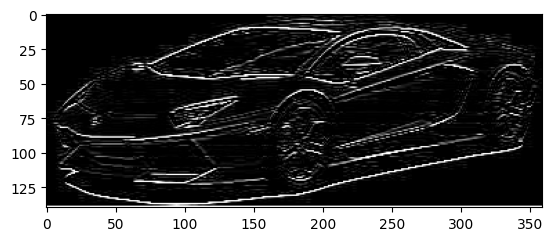

In [ ]:
#Create a kernel to detect horizontal lines
horizontal_kernel = np.array([[-1, -1, -1],
                              [2, 2, 2],
                              [-1, -1, -1]])

#Apply the kernel to the image
transf_horizontal = conv_2d_kernel(input_img_arr, kernel = horizontal_kernel)

#Plot the resulting image
plt.imshow(transf_horizontal, cmap = plt.get_cmap('gray'))

### Questions 01-a and 01-b

#### 01-a: Based on the kernels represented on the above image, create a kernel to detect 45 degree lines using convolution, apply to the car's image and plot the result

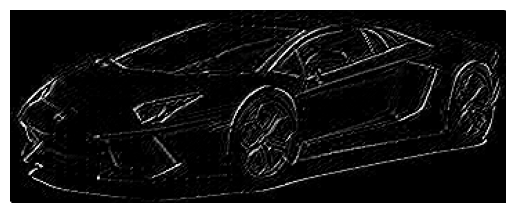

In [ ]:
# Type your code here

# Kernel to detect 45 degree lines
kernel_45 = np.array([[-1, -1,  2],
                      [-1,  2, -1],
                      [ 2, -1, -1]])

# Apply kernel to image
transf_45 = conv_2d_kernel(input_img_arr, kernel=kernel_45)

# Plot
plt.imshow(transf_45, cmap=plt.get_cmap('gray'))
plt.axis('off')
plt.show()

#### 01-b: Based on the kernels represented on the above image, create a kernel to detect 135 degree lines using convolution, apply to the car's image and plot the result

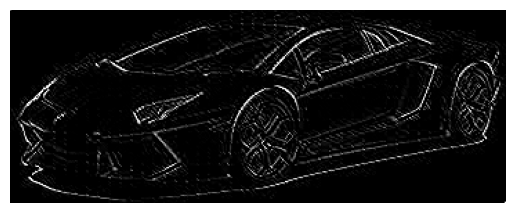

In [ ]:
# Type your code here

# Kernel to detect 135 degree lines
kernel_135 = np.array([[ 2, -1, -1],
                       [-1,  2, -1],
                       [-1, -1,  2]])

# Apply kernel to image
transf_135 = conv_2d_kernel(input_img_arr, kernel=kernel_135)

# Plot
plt.imshow(transf_135, cmap=plt.get_cmap('gray'))
plt.axis('off')
plt.show()


## Edge Detection

### Question 02: Apply the following kernels to your image and plot the output

#### 02-a:

In [ ]:
edge_kernel_1 = np.array([[1, 0, -1],
                          [0, 0, 0],
                          [-1, 0, 1]])

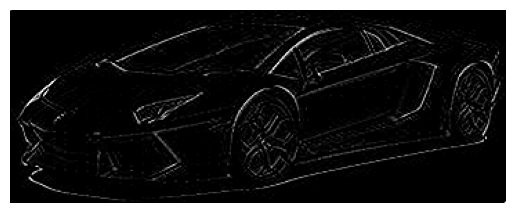

In [ ]:
# Type your code here

# Apply edge_kernel_1 to image
transf_edge1 = conv_2d_kernel(input_img_arr, kernel=edge_kernel_1)

# Plot
plt.imshow(transf_edge1, cmap=plt.get_cmap('gray'))
plt.axis('off')
plt.show()

#### 02-b:

In [ ]:
edge_kernel_2 = np.array([[0, 1, 0],
                          [1, -4, 1],
                          [0, 1, 0]])

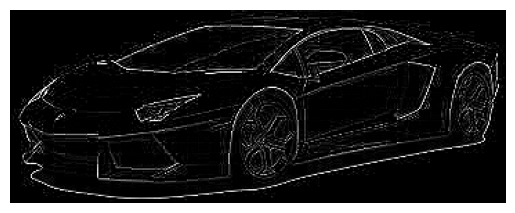

In [ ]:
# Type your code here

# Apply edge_kernel_2 to image
transf_edge2 = conv_2d_kernel(input_img_arr, kernel=edge_kernel_2)

# Plot the result
plt.imshow(transf_edge2, cmap=plt.get_cmap('gray'))
plt.axis('off')
plt.show()

#### 02-c:

In [ ]:
edge_kernel_3 = np.array([[-1, -1, -1],
                          [-1, 8, -1],
                          [-1, -1, -1]])

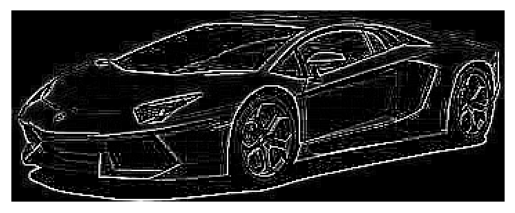

In [ ]:
# Type your code here

#Apply edge_kernel_3 to image
transf_edge3 = conv_2d_kernel(input_img_arr, kernel=edge_kernel_3)

# Plot the result
plt.imshow(transf_edge3, cmap=plt.get_cmap('gray'))
plt.axis('off')
plt.show()


# PART B

## Importing Libraries

In [ ]:
# Import the necessary packages and libraries
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from keras.constraints import max_norm
from keras.datasets import cifar10

## Preparing the dataset

Read more about cifar10 dataset here
https://www.cs.toronto.edu/~kriz/cifar.html

In [ ]:
#load the dataset
(train_images, train_labels),(test_images, test_labels) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [ ]:
# one hot encode target values
train_labels = to_categorical(train_labels,10)
test_labels = to_categorical(test_labels,10)

# convert from integers to floats
train_images = train_images.astype('float32')
test_images = test_images.astype('float32')

# normalize to range 0-1
train_images = train_images / 255.0
test_images = test_images / 255.0

## Building the neural network model

In [ ]:
# Create the model
model = keras.Sequential([
          keras.layers.Conv2D(32, (3,3), padding='same',
                              activation='relu',
                              kernel_constraint=max_norm(3),
                              input_shape=(32, 32, 3)),
          keras.layers.MaxPooling2D((2, 2)),
          keras.layers.Flatten(),
          keras.layers.Dense(128, activation='relu'),
          keras.layers.Dense(10, activation='softmax'),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Model compilation
model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Display a summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,050,890 (4.01 MB)

 Trainable params: 1,050,890 (4.01 MB)

 Non-trainable params: 0 (0.00 B)

## CustomCallback class for logging

In [ ]:
# Create a Custom Callback class to be called during the training
class CustomCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(epoch % 5 ==0):
      print(" Finished epoch #",epoch)
      print('Accuracy resched train is',logs.get('accuracy'))
      print('Accuracy reached val is',logs.get('val_accuracy'))
      print()
      return

In [ ]:
# Instantiate the Custom Callback
cc=CustomCallback()

## Training the Nework

In [ ]:
# Train the Network with train_images and train_labels
history = model.fit(train_images,
                    train_labels,
                    epochs=50,
                    batch_size=256,
                    verbose=0,
                    validation_data=(test_images,test_labels),
                    callbacks=[cc])

 Finished epoch # 0
Accuracy resched train is 0.39438000321388245
Accuracy reached val is 0.5056999921798706

 Finished epoch # 5
Accuracy resched train is 0.6341999769210815
Accuracy reached val is 0.6067000031471252

 Finished epoch # 10
Accuracy resched train is 0.6897799968719482
Accuracy reached val is 0.6277999877929688

 Finished epoch # 15
Accuracy resched train is 0.7344599962234497
Accuracy reached val is 0.6406999826431274

 Finished epoch # 20
Accuracy resched train is 0.766260027885437
Accuracy reached val is 0.633400022983551

 Finished epoch # 25
Accuracy resched train is 0.7944999933242798
Accuracy reached val is 0.6523000001907349

 Finished epoch # 30
Accuracy resched train is 0.822700023651123
Accuracy reached val is 0.6486999988555908

 Finished epoch # 35
Accuracy resched train is 0.8464999794960022
Accuracy reached val is 0.6539999842643738

 Finished epoch # 40
Accuracy resched train is 0.8734400272369385
Accuracy reached val is 0.6381000280380249

 Finished epoc

## Plotting the Results

In [ ]:
# Define a function to plot the results
def result_plotting():
  plt.figure(figsize=[8,6])
  plt.plot(history.history['accuracy'],'blue',linewidth=3.0)
  plt.plot(history.history['val_accuracy'],'red',ls='--',linewidth=3.0)
  plt.legend(['Training Accuracy','Validaion Accuracy'],fontsize=18,loc='lower right')
  plt.xlabel('Epochs',fontsize=16)
  plt.ylabel('Accuracy',fontsize=16)
  plt.title('Accuracy Curves',fontsize=16)

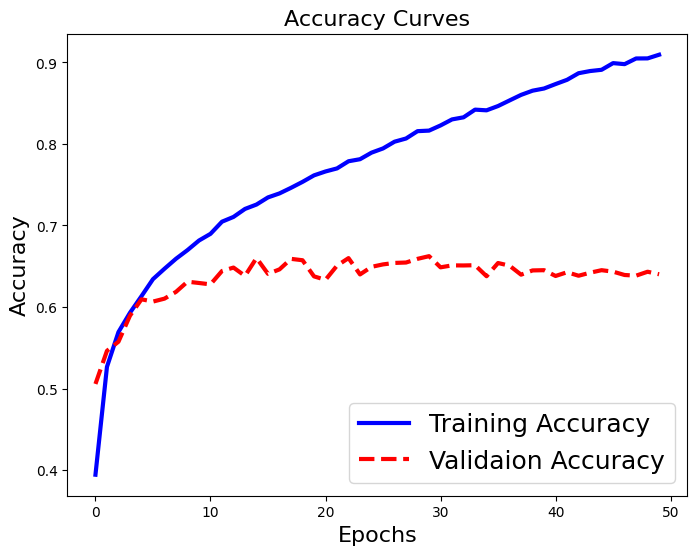

In [ ]:
# Call the result_plotting() function
result_plotting()

### Questions 03 to 10

#### 03: Did the network present signs of overfitting? If so, in which epoch?

Answer:
The network shows signs of overfitting. It begins around epoch 25-30, when the training accuracy continues increasing while the validation accuracy stops improving and starts to decrease slightly.

#### 04: Write down how many layers this model has and identify their types

Answer:
1. Conv2D – Convolutional layer

2. MaxPooling2D – Pooling layer

3. Flatten – Converts feature maps into a vector

4. Dense – Fully connected layer (128 neurons)

5. Dense – Output layer (10 neurons, softmax activation)

#### 05: Briefly explain what is the purpose of each of those layers

Answer:


*   Conv2D: Detects important features in the image such as edges, shapes, and textures.
*   MaxPooling2D: Reduces the size of the feature maps while keeping the most important information.
*   Flatten: Converts the 2D feature maps into a 1D vector so it can be used by dense layers.
*   Dense (128): Learns patterns from the extracted features and performs classification.
*   Dense (10): Output layer that predicts the probability for each of the 10 CIFAR-10 classes using softmax.





#### 06: Add one or more Convolution layers to your model and run it again.

> Hint: Don't modify the given code. Instead, copy and paste the given code below, then:
1. modify it to answer the current question
2.  run the cell below containing the fucntions ```model.compile()``` and ```model.fit()```.
3. once the training is complete, run the following cell containing the ```result_plotting()``` function

In [ ]:
# Type your code here

# Create model
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), padding='same',
                        activation='relu',
                        kernel_constraint=max_norm(3),
                        input_shape=(32, 32, 3)),
    keras.layers.Conv2D(32, (3,3), padding='same',
                        activation='relu',
                        kernel_constraint=max_norm(3)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax'),
])

In [ ]:
# Compile your new model
model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])

# Train the Neural Network with your new model
history = model.fit(train_images,
                    train_labels,
                    epochs=50,
                    batch_size=256,
                    verbose=0,
                    validation_data=(test_images,test_labels),
                    callbacks=[cc])

 Finished epoch # 0
Accuracy resched train is 0.4634599983692169
Accuracy reached val is 0.5566999912261963

 Finished epoch # 5
Accuracy resched train is 0.7468600273132324
Accuracy reached val is 0.6617000102996826

 Finished epoch # 10
Accuracy resched train is 0.8586599826812744
Accuracy reached val is 0.6887999773025513

 Finished epoch # 15
Accuracy resched train is 0.9513199925422668
Accuracy reached val is 0.6743999719619751

 Finished epoch # 20
Accuracy resched train is 0.9924799799919128
Accuracy reached val is 0.6693999767303467

 Finished epoch # 25
Accuracy resched train is 0.9973000288009644
Accuracy reached val is 0.6783000230789185

 Finished epoch # 30
Accuracy resched train is 0.9998999834060669
Accuracy reached val is 0.6751999855041504

 Finished epoch # 35
Accuracy resched train is 1.0
Accuracy reached val is 0.6769000291824341

 Finished epoch # 40
Accuracy resched train is 1.0
Accuracy reached val is 0.6744999885559082

 Finished epoch # 45
Accuracy resched trai

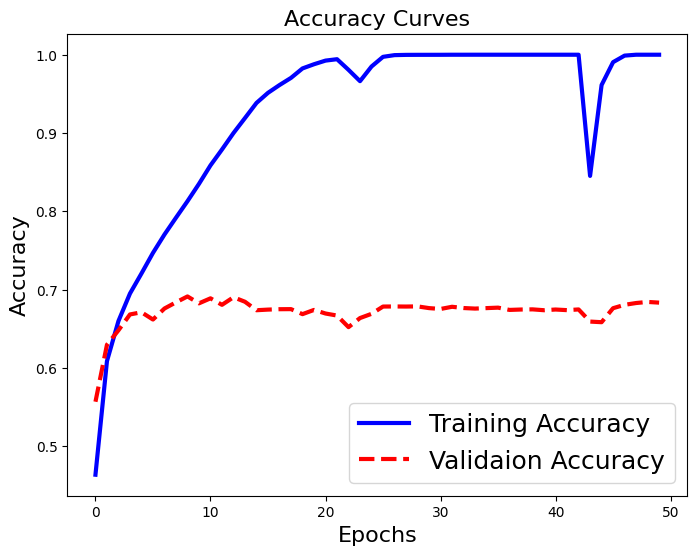

In [ ]:
# Call the result_plotting() to display the results from your code
result_plotting()

#### 07: Compare the results between the orinal model made using keras.Sequential VS the bigger model with at least 1 extra layer added.  Describe what are the differences between them.

Answer: The bigger model achieved higher training accuracy and slightly better validation accuracy than the original model. It also showed more overfitting, since the training accuracy became much higher than the validation accuracy.

#### 08: Add a dropout layer to your model, run it, and compare the result with the previous one.

> Hint 1: Here is a good explanation on how dropouts work https://www.youtube.com/watch?v=bRyOi0L6Rs8

> Hint 2: Don't modify the given code. Instead, copy and paste the given code below, then:
1. Modify it to add a dropout layer
2. Run the cell below containing the fucntions ```model.compile()``` and ```model.fit()```.
3. Once the training is complete, run the following cell containing the ```result_plotting()``` function




In [ ]:
# Type your code here

from keras.layers import Dropout

# Create the model
model = keras.Sequential([
          keras.layers.Conv2D(32, (3,3), padding='same',
                              activation='relu',
                              kernel_constraint=max_norm(3),
                              input_shape=(32, 32, 3)),
          keras.layers.Conv2D(32, (3,3), padding='same',
                              activation='relu',
                              kernel_constraint=max_norm(3)),
          keras.layers.MaxPooling2D((2, 2)),
          keras.layers.Flatten(),
          keras.layers.Dense(128, activation='relu'),
          Dropout(0.5),   # Dropout layer added
          keras.layers.Dense(10, activation='softmax'),
])

In [ ]:
# Compile your new model
model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])

# Train the Neural Network with your new model
history = model.fit(train_images,
                    train_labels,
                    epochs=50,
                    batch_size=256,
                    verbose=0,
                    validation_data=(test_images,test_labels),
                    callbacks=[cc])

 Finished epoch # 0
Accuracy resched train is 0.379940003156662
Accuracy reached val is 0.531000018119812

 Finished epoch # 5
Accuracy resched train is 0.6460000276565552
Accuracy reached val is 0.663100004196167

 Finished epoch # 10
Accuracy resched train is 0.7081199884414673
Accuracy reached val is 0.6927000284194946

 Finished epoch # 15
Accuracy resched train is 0.754800021648407
Accuracy reached val is 0.6949999928474426

 Finished epoch # 20
Accuracy resched train is 0.7950599789619446
Accuracy reached val is 0.6913999915122986

 Finished epoch # 25
Accuracy resched train is 0.819599986076355
Accuracy reached val is 0.6872000098228455

 Finished epoch # 30
Accuracy resched train is 0.8415600061416626
Accuracy reached val is 0.6895999908447266

 Finished epoch # 35
Accuracy resched train is 0.8609200119972229
Accuracy reached val is 0.6858999729156494

 Finished epoch # 40
Accuracy resched train is 0.8748800158500671
Accuracy reached val is 0.6840000152587891

 Finished epoch #

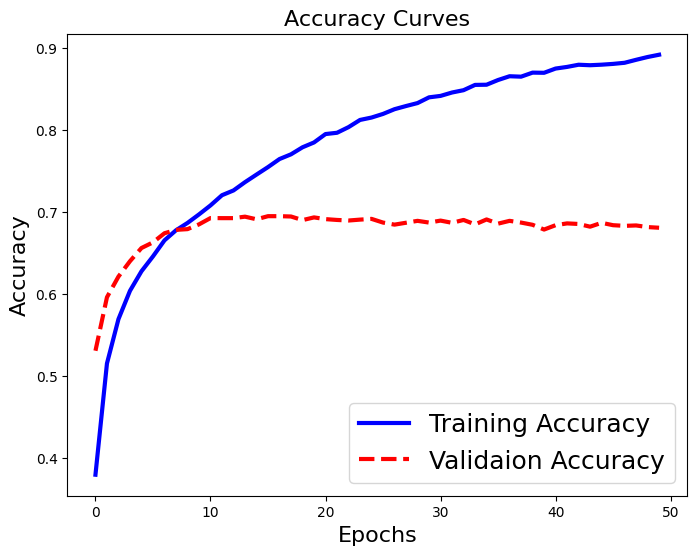

In [ ]:
# Call the result_plotting() to display the results from your code
result_plotting()

#### 09: Explain with your own words what is the purpose of a dropout layer and how it works. And briefly explain in your video in your own words.

Answer: A dropout layer helps reduce overfitting in a neural network. During training, it randomly turns off (drops) some neurons so the model cannot rely too much on specific features. This forces the network to learn more general patterns instead of memorizing the training data. The model usually performs better on new, unseen data.

> Add blockquote



Submission Instructions:
- YOU MUST SUBMIT A LINK TO YOUR ONLINE VIDEO (Youtube, Vimeo, etc) as a COMENTS SUBMISSION SECTION on your D2L SUBMISSION. Omitting this comment will result in a 0% for your total mark. Video should be between 5-15 minutes. Please remember to make your video unlisted or public, but it cannot be private. Please verify it's accessible using an incongito tab.  (5%)

- The Assignment03 **ipynb file** that contains all the code. (5%)
